# TBRGS Separate Training + Visualisation Notebook

This notebook is suitable as an assignment analysis artifact: it trains the three models directly on the preprocessed dataset and visualises their performance.

It uses the prepared data pipeline, then evaluates each model on held-out data to compare metrics.

It does not replace the required CLI/GUI behavior; it documents evidence of model comparison.

In [ ]:
from __future__ import annotations

from datetime import datetime
from pathlib import Path
import pandas as pd
from IPython.display import display

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for _ in range(8):
        if (current / '2B' / 'tbrgs' / 'pipeline.py').exists():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise FileNotFoundError('Could not find project root containing 2B/tbrgs/pipeline.py')

PROJECT_ROOT = find_project_root(Path.cwd())
CONFIG_PATH = PROJECT_ROOT / '2B' / 'config' / 'tbrgs_defaults.json'
OUTPUT_DIR = PROJECT_ROOT / '2B' / 'data' / 'output' / 'notebook_runs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TBRGS_PY_PATH = PROJECT_ROOT / '2B'
import sys
if str(TBRGS_PY_PATH) not in sys.path:
    sys.path.insert(0, str(TBRGS_PY_PATH))

from tbrgs.pipeline import build_context

print('Project root:', PROJECT_ROOT)
print('Output dir:', OUTPUT_DIR)

In [ ]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec('xlrd') is None:
    print('Installing xlrd for .xls support...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xlrd>=2.0.1'])
else:
    print('xlrd is already available.')

In [ ]:
RUN_ORIGIN = 2000
RUN_DESTINATION = 3002
RUN_TOP_K = 5
RUN_ALGO = 'CUS2'
RUN_HOUR = 9
MODELS_TO_RUN = ['lstm', 'gru', 'rf']

RUN_TAG = datetime.now().strftime('%Y%m%d_%H%M%S')
print('Run tag:', RUN_TAG)

In [ ]:
def train_model_run(model_name: str) -> dict:
    selected_models = [model_name]
    print(f'Training model={model_name}')
    ctx = build_context(str(CONFIG_PATH), selected_models=selected_models)
    metrics_df = ctx.metrics_summary.copy()
    metrics_df = metrics_df[metrics_df['model'].isin(selected_models)].copy()

    return {
        'requested_model': model_name,
        'metrics_df': metrics_df,
    }

run_outputs = []
for model in MODELS_TO_RUN:
    run_outputs.append(train_model_run(model))

pd.DataFrame([{'requested_model': item['requested_model']} for item in run_outputs])

In [19]:
frames = []
for item in run_outputs:
    df = item['metrics_df'].copy()
    df['run_requested_model'] = item['requested_model']
    frames.append(df)

all_metrics = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
display(all_metrics.head())
print('Rows:', len(all_metrics))
print('Models present:', sorted(all_metrics['model'].dropna().unique().tolist()) if not all_metrics.empty else [])

,model,samples,mae,rmse,mape,inference_seconds,site_id,run_requested_model
0,lstm,112,1086.936781,1221.719350,180.098334,0.440388,970,lstm
1,lstm,112,897.366019,1080.730156,98.878306,0.377765,2000,lstm
2,lstm,112,583.954200,671.566212,197.776943,0.394565,2200,lstm
3,lstm,112,393.438656,440.346018,168.917789,0.393354,2820,lstm
4,lstm,112,243.314158,296.531528,159.076754,0.628556,2825,lstm


Rows: 120
Models present: ['gru', 'lstm', 'rf']


In [23]:
summary = (
    all_metrics.groupby(['run_requested_model', 'model'], as_index=False)
    .agg(
        mae=('mae', 'mean'),
        rmse=('rmse', 'mean'),
        mape=('mape', 'mean'),
        inference_seconds=('inference_seconds', 'mean'),
        site_count=('site_id', 'nunique')
    )
    .sort_values(['run_requested_model', 'rmse'])
)

display(summary)

,run_requested_model,model,mae,rmse,mape,inference_seconds,site_count
0,gru,gru,452.732628,534.577617,113.632108,0.517795,40
1,lstm,lstm,576.723980,667.555076,152.282837,0.449524,40
2,rf,rf,172.035298,252.061995,22.436057,0.032861,40


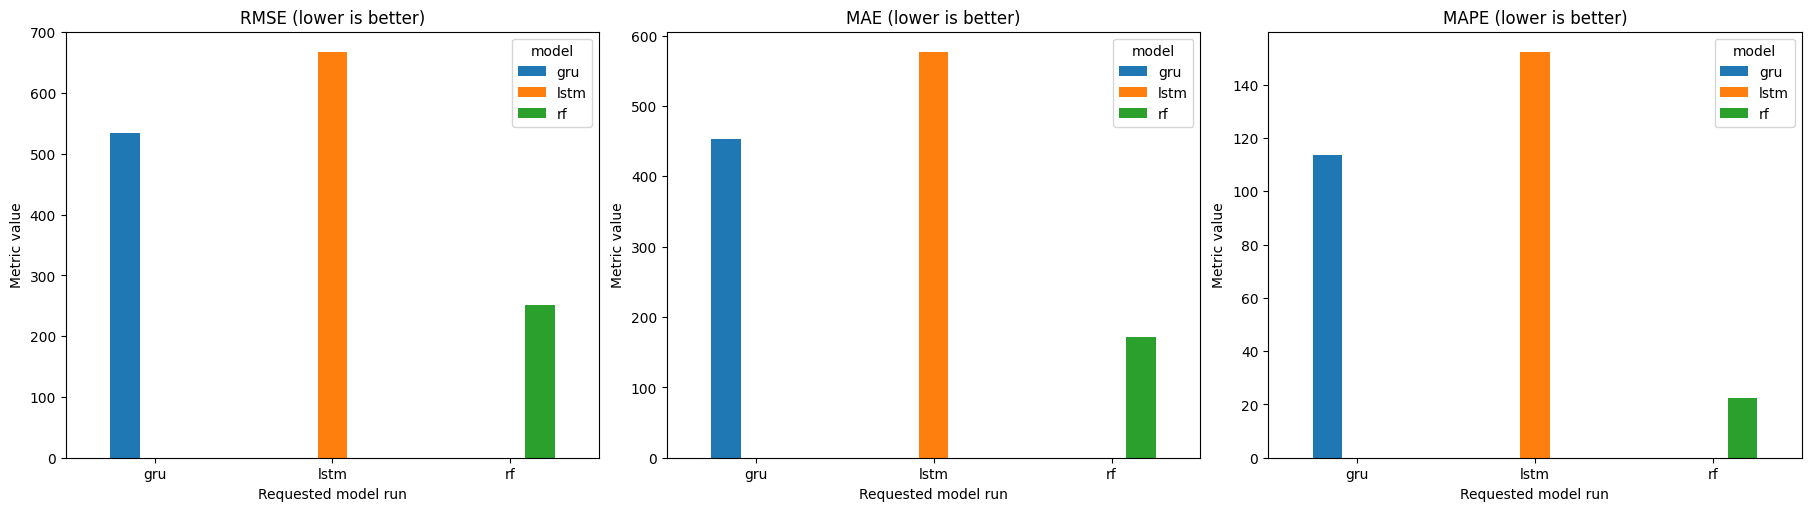

In [24]:
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

    pivot_rmse = summary.pivot(index='run_requested_model', columns='model', values='rmse')
    pivot_mae = summary.pivot(index='run_requested_model', columns='model', values='mae')
    pivot_mape = summary.pivot(index='run_requested_model', columns='model', values='mape')

    pivot_rmse.plot(kind='bar', ax=axes[0], title='RMSE (lower is better)')
    pivot_mae.plot(kind='bar', ax=axes[1], title='MAE (lower is better)')
    pivot_mape.plot(kind='bar', ax=axes[2], title='MAPE (lower is better)')

    for ax in axes:
        ax.set_xlabel('Requested model run')
        ax.set_ylabel('Metric value')
        ax.tick_params(axis='x', rotation=0)

    plt.show()
except Exception as exc:
    print('Matplotlib chart skipped:', exc)
    print('You can install it in this env with:')
    print('  python -m pip install matplotlib')